# Sentiment Analysis: Bank marketing campaigns dataset | Opening Deposit
The dataset **Bank marketing campaigns dataset | Opening Deposit** describes Portugal bank marketing campaigns, marking efforts by client to agree to place a deposit. 
- The target(y), "has the client subscribed a term deposit? " which could be either 'yes' or 'no' response.

# Research questions:
i. Which client characteristics (e.g., age, job, marital status, education level) are most commonly targeted in marketing campaigns?

ii. Which factors (e.g., job type, marital status, education, credit default status, housing loan, personal loan, balance) most significantly predict the likelihood of subscribing to a term deposit?

iii. What is the overall success rate of the marketing campaigns in terms of subscription?

iv. Can clients be segmented into distinct groups based on their likelihood to subscribe?

v. What are the key performance metrics (e.g., accuracy, precision, recall) for these models?

In [1]:
#importing libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
# read the dataset
df = pd.read_csv("C:/Users/DISCOVERY/Machine_Learning/Datasets/bank-additional-full.csv/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [29]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [30]:
df.shape

(41188, 21)

In [37]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [31]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


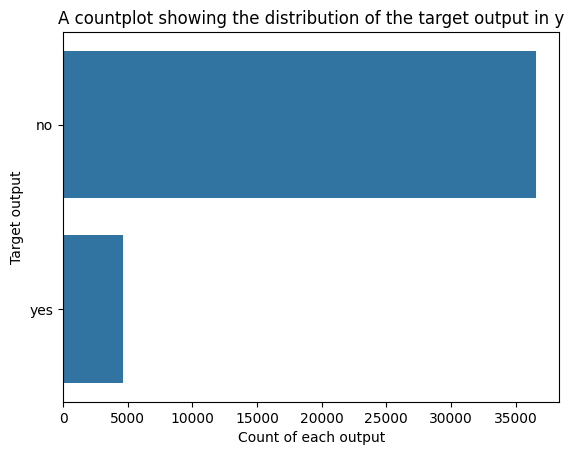

In [6]:
# check distribution for the target output in y
sns.countplot(y=df['y'], data=df)
plt.title("A countplot showing the distribution of the target output in y")
plt.xlabel("Count of each output")
plt.ylabel("Target output")
plt.show()

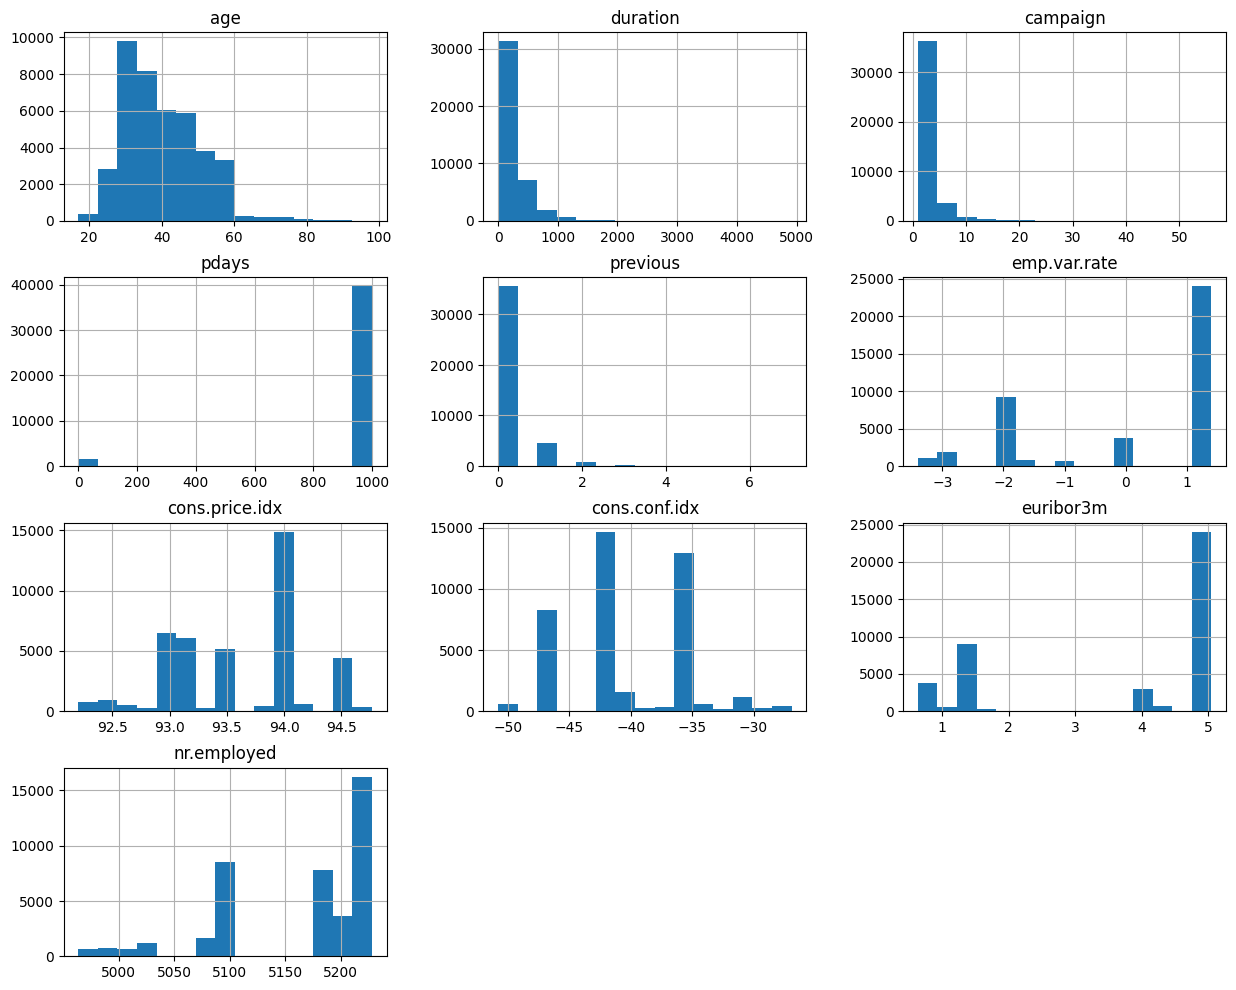

In [7]:
df.hist(figsize=(15,12), bins = 15)
plt.title("Feature Distribution")
plt.show()

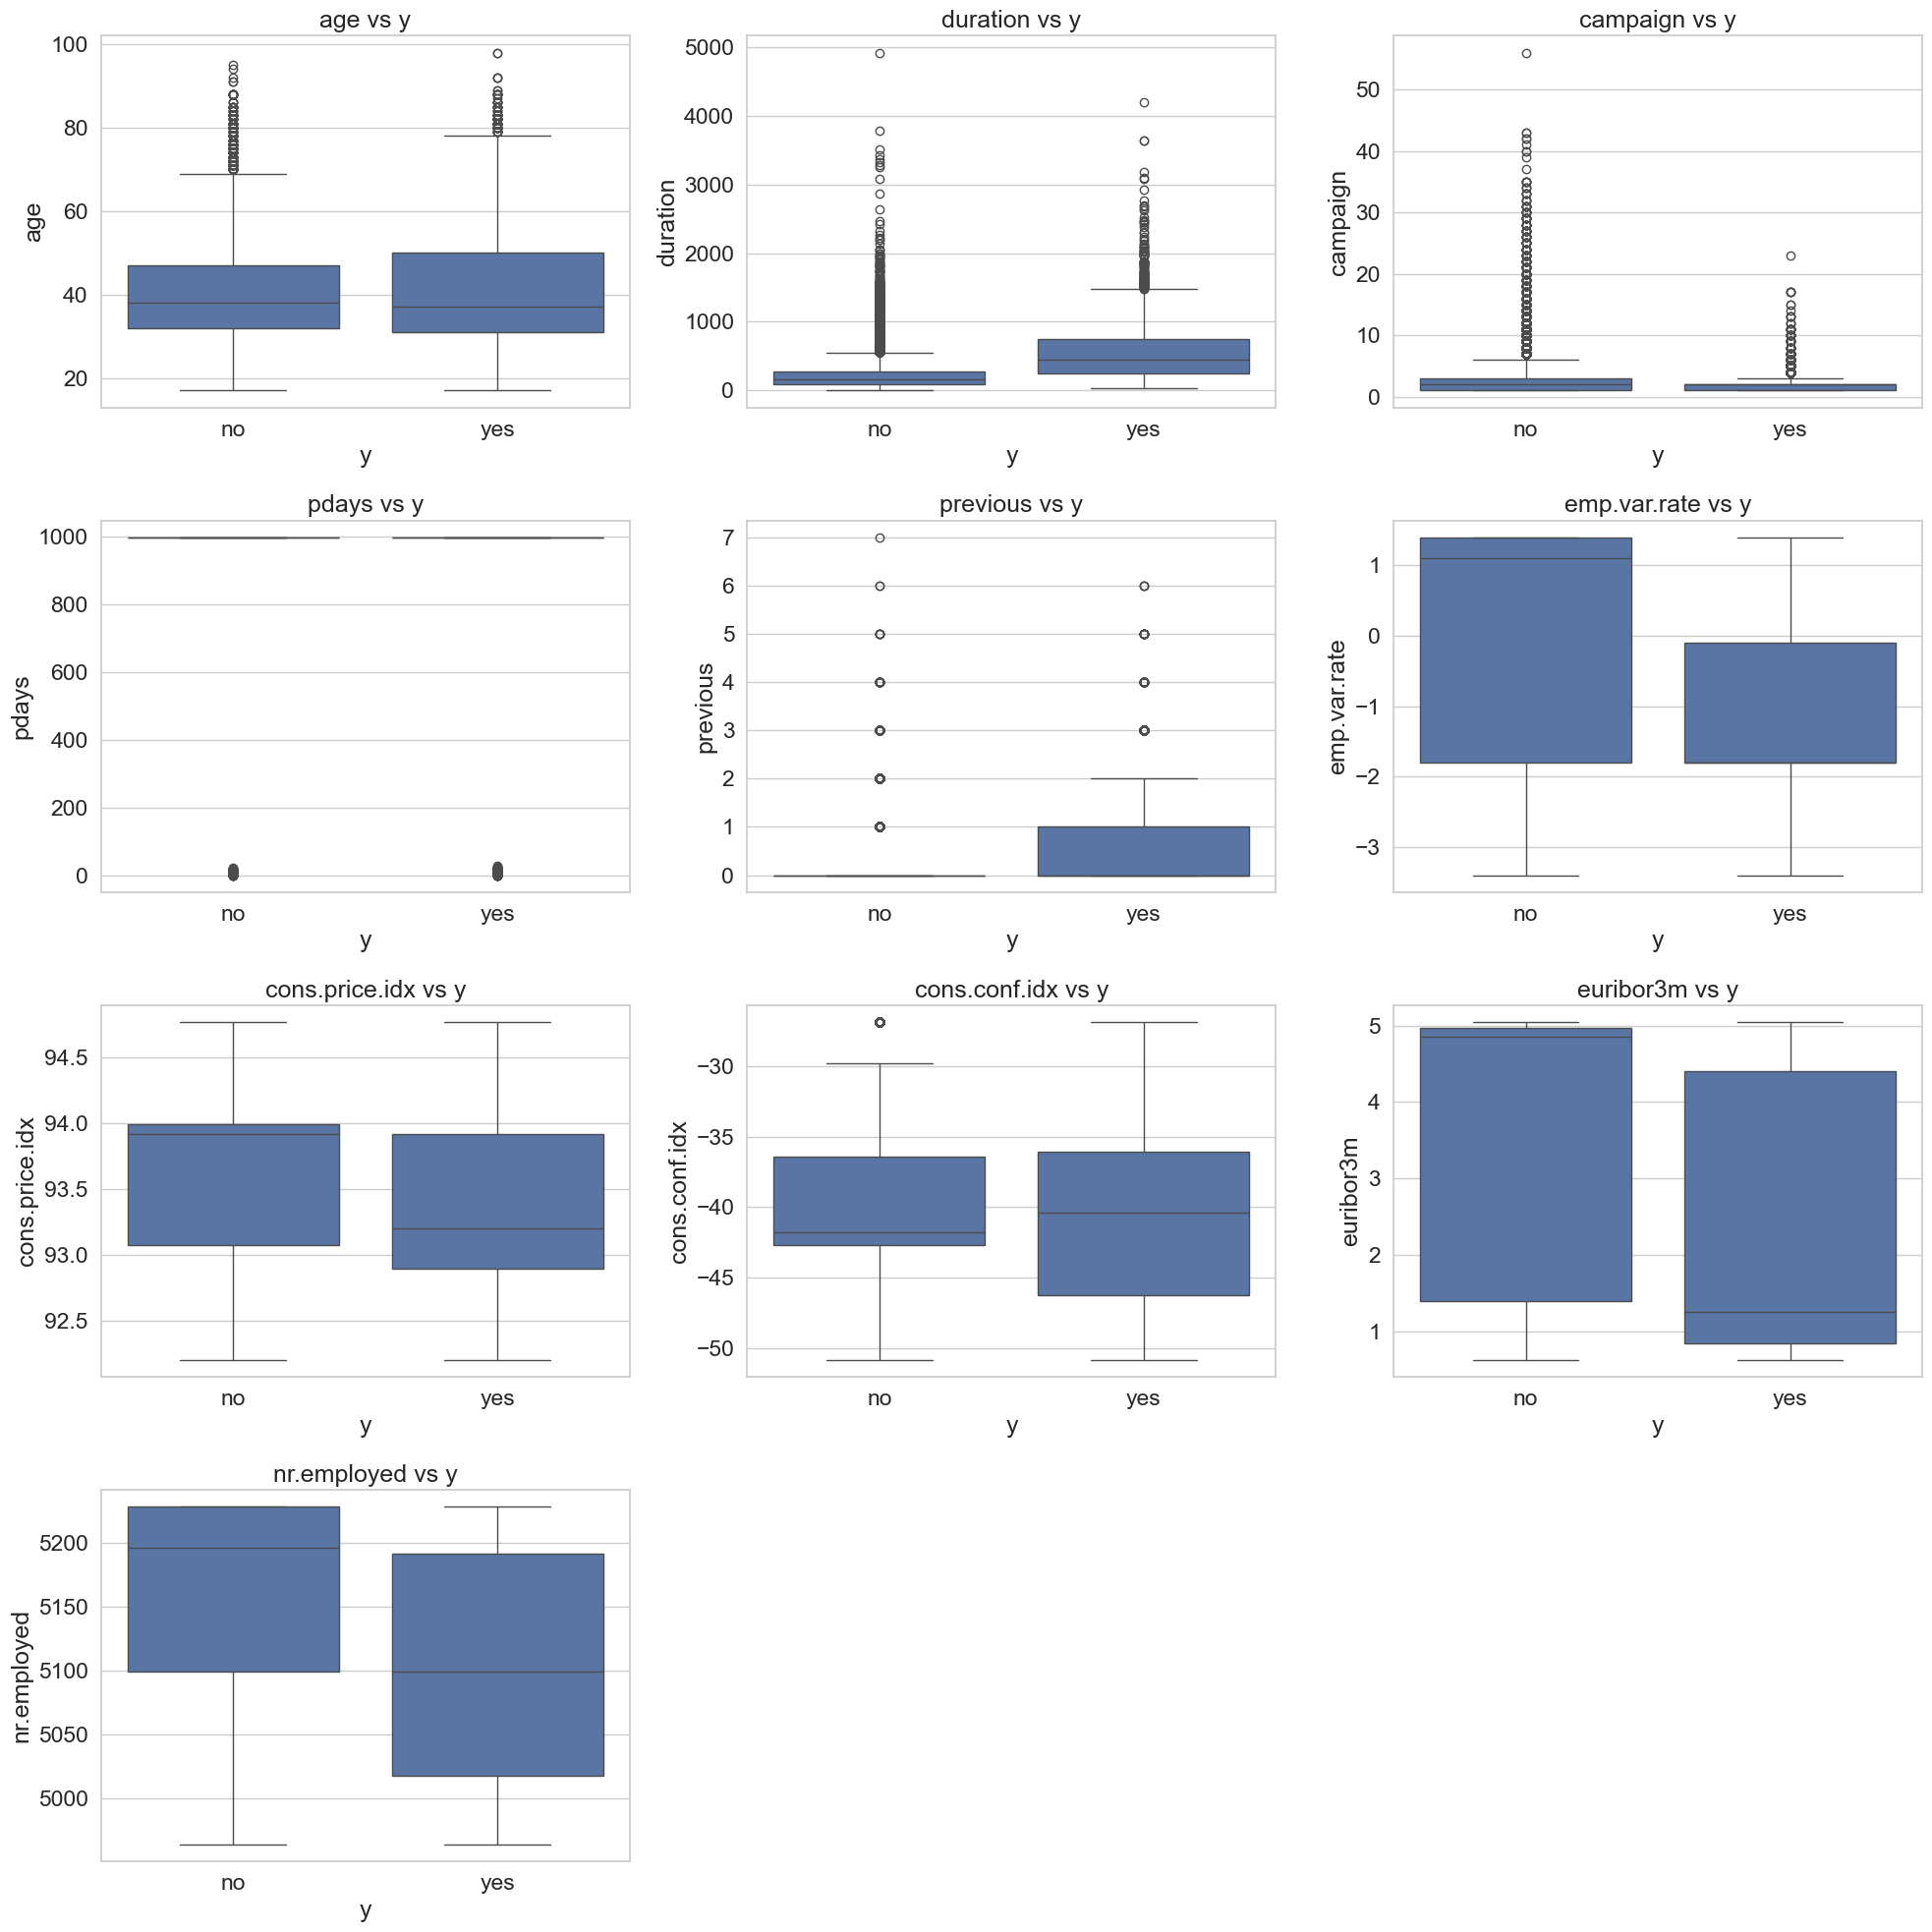

In [19]:
# Get numeric columns
input_num_columns = df.select_dtypes(include='number').columns

# Define grid size
n_cols = 3

import math
n_rows = math.ceil(len(input_num_columns)/n_cols)

sns.set(style="whitegrid", font_scale=1.5)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*5))

# Ensure axes is always a flat array
axes = np.atleast_1d(axes).flatten()

# Plot each numeric column against 'y'
for idx, col_name in enumerate(input_num_columns):
    sns.boxplot(x=df['y'], y=df[col_name], ax=axes[idx])
    axes[idx].set_title(f'{col_name} vs y')

# Turn off any unused subplots
for j in range(len(input_num_columns), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# The goal of this study is to use sentiment analysis with "customer response" text and predict whether a customer will open a deposit account y; 
# (y = 'yes' or 'no').

In [38]:
#Simulate Customer Text Responses
np.random.seed(42)

def generate_response(row):
    if row['y'] == 'yes':
        return np.random.choice([
            "I'm really super excited",
        ])
    elif row['poutcome'] == 'failure':
        return np.random.choice([
            "I'm not yet convinced"
        ])
    elif row['poutcome'] == 'nonexistent':
        return np.random.choice([
            "I have no idea about all this."
        ])
    else:
        return "I'm still deciding. Need more time to think."

df['customer_response'] = df.apply(generate_response, axis=1)


In [39]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,customer_response
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,I have no idea about all this.
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,I have no idea about all this.
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,I have no idea about all this.
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,I have no idea about all this.
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,I have no idea about all this.


In [40]:
pip install nltk


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 599.8 kB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.5 MB 599.8 kB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.5 MB 599.8 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 486.5 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 486.5 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 486.5 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/

In [42]:
pip install vaderSentiment


Note: you may need to restart the kernel to use updated packages.


In [44]:
#Text Preprocess and Sentiment Analyze
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download required NLTK data (run this once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Initialize components
stop_words = set(stopwords.words('english'))
analyzer = SentimentIntensityAnalyzer()

def clean_text(text):
    if pd.isna(text) or text == '':  # Handle NaN and empty values
        return ''
    tokens = word_tokenize(str(text).lower())
    return ' '.join([t for t in tokens if t.isalpha() and t not in stop_words])

# Apply cleaning
df['clean_response'] = df['customer_response'].apply(clean_text)

# Extract sentiment scores using VADER
df['sentiment'] = df['clean_response'].apply(lambda x: analyzer.polarity_scores(str(x)))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DISCOVERY\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DISCOVERY\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DISCOVERY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DISCOVERY\AppData\Roaming\nltk_data...


In [53]:
#Data preparation for Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Target variable
df['y_bin'] = df['y'].map({'yes': 1, 'no': 0})

# Features: include original structured + sentiment
cat_feats = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']
num_feats = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
sentiment_feats = ['compound', 'pos', 'neu', 'neg']

X = df[cat_feats + num_feats + sentiment_feats]
y = df['y_bin']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
], remainder='passthrough')  # sentiment feats are numeric already


In [54]:
# Model building and Training 
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7303
           1       1.00      1.00      1.00       935

    accuracy                           1.00      8238
   macro avg       1.00      1.00      1.00      8238
weighted avg       1.00      1.00      1.00      8238

ROC AUC: 0.9999999999999999


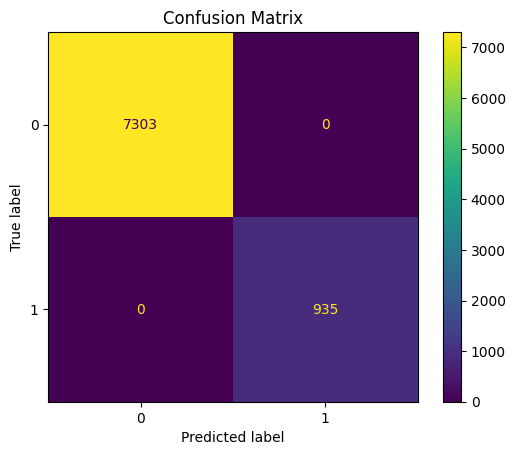

In [57]:
# Model Evaluation 
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()
